# Cloud Access of DEMOGORGN topography simulations

* Simulations are not postprocessed and have some issues
* With realizations stored as netCDF (no icechunk yet)

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import s3fs
from pathlib import Path
import cmcrameri.cm as cm

In [2]:
fs = s3fs.S3FileSystem(anon=True)
s3_url = 's3://us-west-2.opendata.source.coop/englacial/demogorgn/realizations.nc'

file_obj = fs.open(s3_url, mode='rb')

In [3]:
# Use h5netcdf engine for high performance with S3 objects
ds = xr.open_dataarray(file_obj, engine='h5netcdf')
ds

<xarray.DataArray (seed_id: 100, y: 13334, x: 13334)> Size: 71GB
[17779555600 values with dtype=float32]
Coordinates:
  * seed_id  (seed_id) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * y        (y) float32 53kB 3.333e+06 3.333e+06 ... -3.333e+06 -3.333e+06
  * x        (x) float32 53kB -3.333e+06 -3.333e+06 ... 3.333e+06 3.333e+06

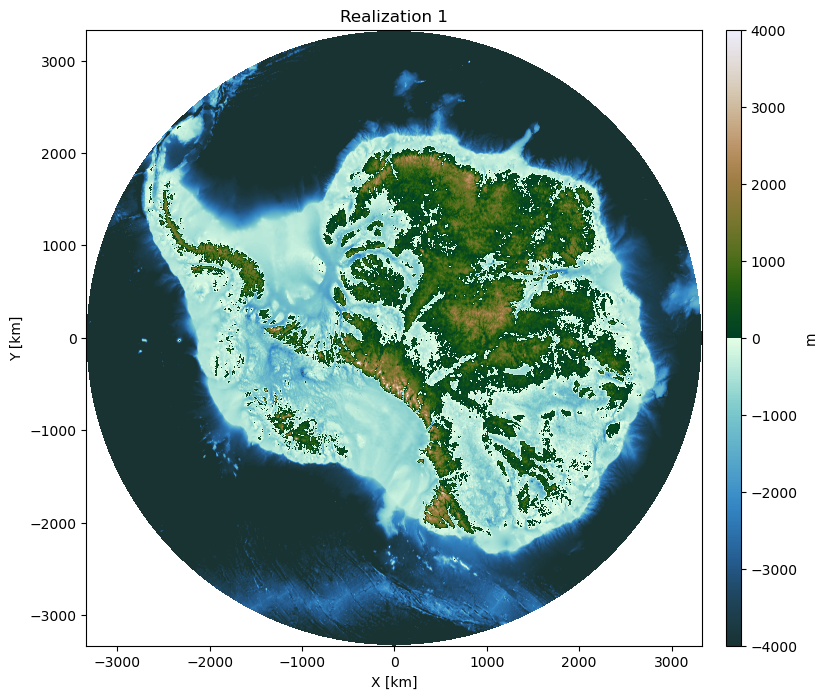

In [4]:
extent=[ds.x.values.min()/1000, ds.x.values.max()/1000, ds.y.values.min()/1000, ds.y.values.max()/1000]

plt.figure(figsize=(10,8))
plt.imshow(ds.sel(seed_id=0), extent=extent, vmin=-4000, vmax=4000, cmap=cm.bukavu)
plt.title('Realization 1')
plt.xlabel('X [km]')
plt.ylabel('Y [km]')
plt.colorbar(pad=0.03, aspect=40, label='m', extend='both')
plt.show()

## Compare realization with Bedmap3 bed topography

In [5]:
bmap = xr.open_dataset(Path('/Volumes/MFIELD/bedmap_interpolation/processed_data/bedmap3_mod_500.nc'))

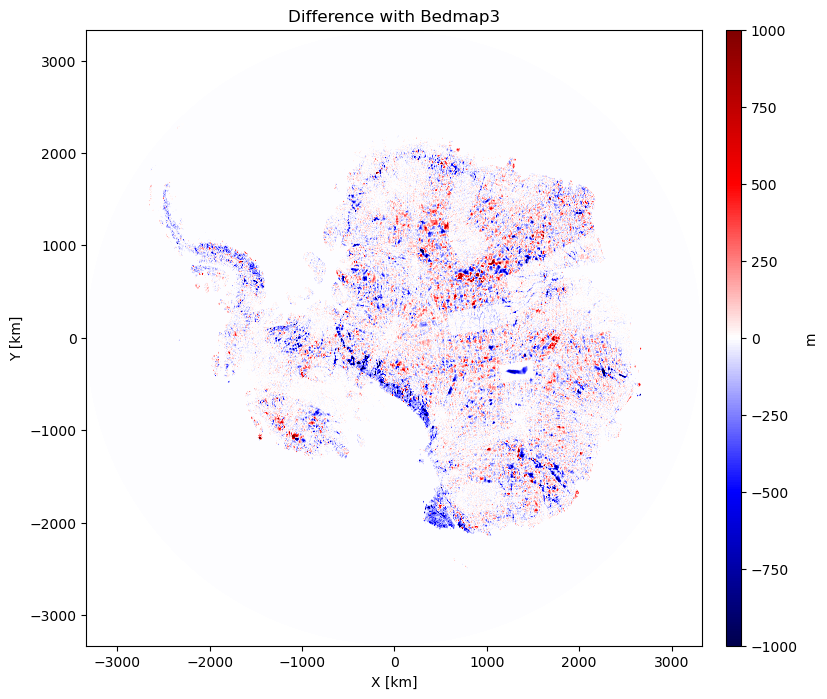

In [6]:
plt.figure(figsize=(10,8))
plt.imshow(bmap.bed_topography.values-ds.sel(seed_id=0), extent=extent, vmin=-1000, vmax=1000, cmap='seismic')
plt.title('Difference with Bedmap3')
plt.xlabel('X [km]')
plt.ylabel('Y [km]')
plt.colorbar(pad=0.03, aspect=40, label='m')
plt.show()

# Trim to area of interest

In [7]:
xmin = -1.4e6
xmax = -1.1e6
ymin = -0.9e6
ymax = -0.6e6

ds_trim = ds.sel(x=slice(xmin, xmax), y=slice(ymax, ymin))
ds_trim

<xarray.DataArray (seed_id: 100, y: 600, x: 600)> Size: 144MB
[36000000 values with dtype=float32]
Coordinates:
  * seed_id  (seed_id) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * y        (y) float32 2kB -6.002e+05 -6.008e+05 ... -8.992e+05 -8.998e+05
  * x        (x) float32 2kB -1.4e+06 -1.399e+06 ... -1.101e+06 -1.1e+06

In [8]:
bmap_trim = bmap.sel(x=slice(xmin, xmax), y=slice(ymax, ymin))

In [9]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

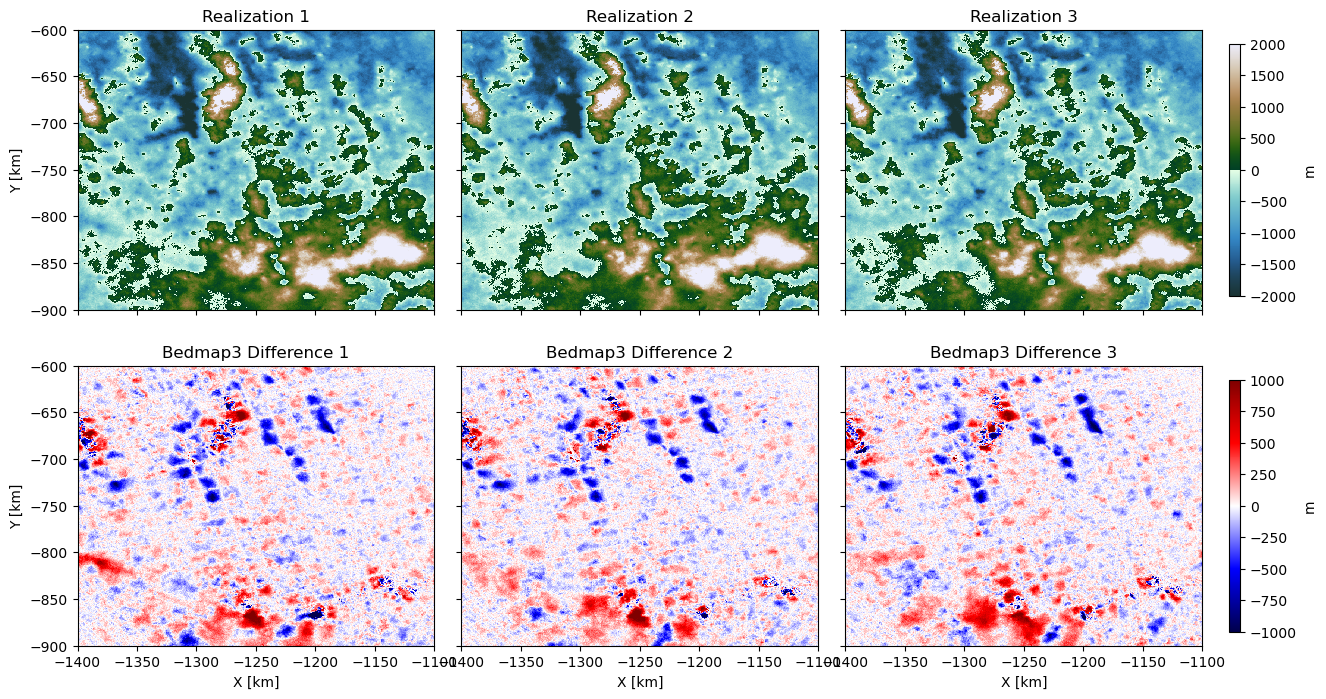

In [10]:
fig = plt.figure(figsize=(15,8))
gspec = GridSpec(2, 4, width_ratios=[1, 1, 1, 0.03], wspace=0.1)

axs1 = []
axs2 = []
for i in range(3):
    axs1.append(fig.add_subplot(gspec[0,i]))
    axs2.append(fig.add_subplot(gspec[1,i]))

for i, ax in enumerate(axs1):
    im1 = ax.pcolormesh(ds_trim.x/1000, ds_trim.y/1000, ds_trim.sel(seed_id=i), vmin=-2000, vmax=2000, cmap=cm.bukavu)
    ax.set_title(f'Realization {i+1}')

for i, ax in enumerate(axs2):
    im2 = ax.pcolormesh(ds_trim.x/1000, ds_trim.y/1000, bmap_trim.bed_topography-ds_trim.sel(seed_id=i), vmin=-1000, vmax=1000, cmap='seismic')
    ax.set_title(f'Bedmap3 Difference {i+1}')
    ax.set_xlabel('X [km]')


axs1[0].set_ylabel('Y [km]')
axs2[0].set_ylabel('Y [km]')

axs1[1].set_yticklabels([])
axs1[2].set_yticklabels([])

axs2[1].set_yticklabels([])
axs2[2].set_yticklabels([])

for i in range(3):
    axs1[i].set_xticklabels([])

gspec2 = GridSpecFromSubplotSpec(100, 1, gspec[0,3])
cax1 = fig.add_subplot(gspec2[5:95])
plt.colorbar(im1, cax=cax1, label='m', extend='both')

gspec3 = GridSpecFromSubplotSpec(100, 1, gspec[1,3])
cax2 = fig.add_subplot(gspec3[5:95])
plt.colorbar(im2, cax=cax2, label='m', extend='both')

plt.show()

In [11]:
beds = ds_trim.sel(seed_id=slice(0,19))
beds

<xarray.DataArray (seed_id: 20, y: 600, x: 600)> Size: 29MB
[7200000 values with dtype=float32]
Coordinates:
  * seed_id  (seed_id) int64 160B 0 1 2 3 4 5 6 7 8 ... 12 13 14 15 16 17 18 19
  * y        (y) float32 2kB -6.002e+05 -6.008e+05 ... -8.992e+05 -8.998e+05
  * x        (x) float32 2kB -1.4e+06 -1.399e+06 ... -1.101e+06 -1.1e+06

In [12]:
mean = beds.mean(dim='seed_id').values
std = beds.std(dim='seed_id').values

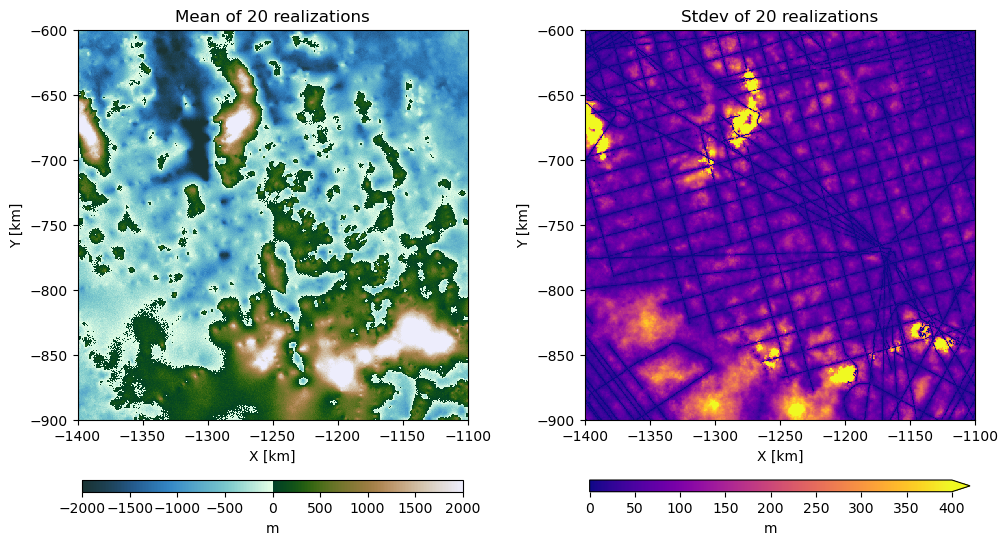

In [13]:
fig = plt.figure(figsize=(12,6))
gspec = GridSpec(2, 2, height_ratios=[1, 0.03], hspace=0.3)

ax1 = fig.add_subplot(gspec[0,0])
ax2 = fig.add_subplot(gspec[0,1])

im1 = ax1.pcolormesh(ds_trim.x/1000, ds_trim.y/1000, mean, vmin=-2000, vmax=2000, cmap=cm.bukavu)
ax1.axis('scaled')
ax1.set_ylabel('Y [km]')
ax1.set_xlabel('X [km]')
ax1.set_title('Mean of 20 realizations')

im2 = ax2.pcolormesh(ds_trim.x/1000, ds_trim.y/1000, std, vmax=400, cmap='plasma')
ax2.axis('scaled')
ax2.set_ylabel('Y [km]')
ax2.set_xlabel('X [km]')
ax2.set_title('Stdev of 20 realizations')

gspec2 = GridSpecFromSubplotSpec(1, 100, gspec[1,0])
cax1 = fig.add_subplot(gspec2[5:95])
plt.colorbar(im1, cax=cax1, label='m', orientation='horizontal')

gspec2 = GridSpecFromSubplotSpec(1, 100, gspec[1,1])
cax1 = fig.add_subplot(gspec2[5:95])
plt.colorbar(im2, cax=cax1, label='m', orientation='horizontal', extend='max')

plt.show()

## Differences between realization 0

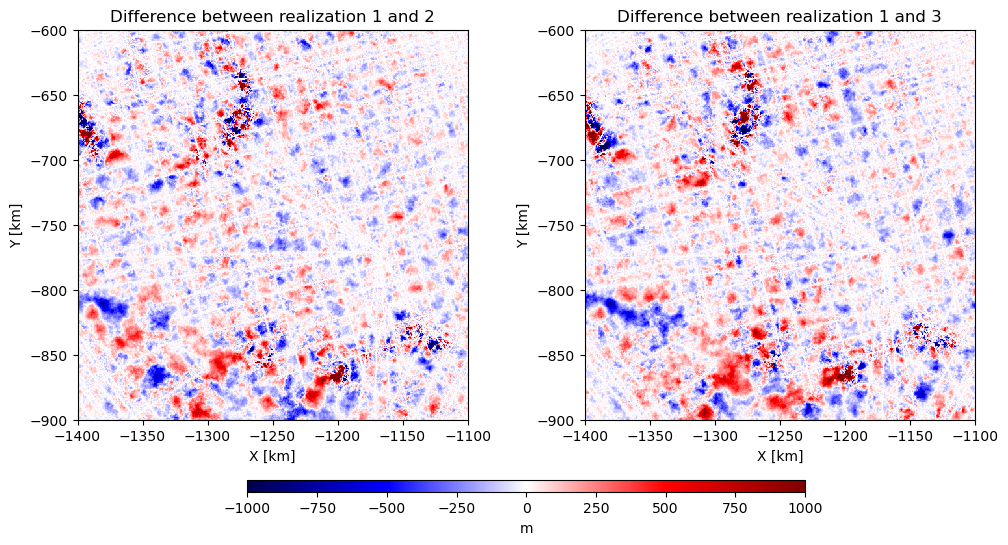

In [14]:
fig = plt.figure(figsize=(12,6))
gspec = GridSpec(2, 2, height_ratios=[1, 0.03], hspace=0.3)

ax1 = fig.add_subplot(gspec[0,0])
ax2 = fig.add_subplot(gspec[0,1])
axs = [ax1, ax2]

for i, ax in enumerate(axs):
    im1 = ax.pcolormesh(ds_trim.x/1000, ds_trim.y/1000, ds_trim.sel(seed_id=0)-ds_trim.sel(seed_id=i+1), vmin=-1000, vmax=1000, cmap='seismic')
    ax.axis('scaled')
    ax.set_ylabel('Y [km]')
    ax.set_xlabel('X [km]')
    ax.set_title(f'Difference between realization 1 and {i+2}')

gspec2 = GridSpecFromSubplotSpec(1, 100, gspec[1,:])
cax1 = fig.add_subplot(gspec2[20:80])
plt.colorbar(im1, cax=cax1, label='m', orientation='horizontal')

plt.show()

In [15]:
file_obj.close()